In [1]:
import dataloader as dl
import numpy as np
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize_scalar
from scipy.stats import bootstrap

In [2]:
# ============================================================
# Autocorrelation & integrated autocorrelation time
# ============================================================

def autocorr(x):
    """Normalised autocorrelation function via FFT."""
    x  = x - x.mean()
    n  = len(x)
    f  = np.fft.rfft(x, n=2 * n)
    ac = np.fft.irfft(f * np.conj(f))[:n]
    ac /= ac[0]
    return ac


def tau_int(x, c=6.0):
    """
    Madras-Sokal windowed estimate of the integrated autocorrelation time with jack-knife error estimate.

    tau_int = 0.5 + sum_{t=1}^{W} rho(t)

    Window W chosen self-consistently:  W = min{ t : t >= c * tau_int(t) }.
    Returns (tau, W, error_estimate).
    """
    # FFT autocorrelation
    def autocorr(x):
        x = x - x.mean()
        n = len(x)
        f = np.fft.rfft(x, n=2*n)
        ac = np.fft.irfft(f * np.conj(f))[:n]
        ac /= ac[0]
        return ac

    # Compute tau_int for full data
    ac = autocorr(x)
    tau = 0.5
    W = len(ac) - 1
    for t in range(1, len(ac)):
        tau += ac[t]
        if t >= c * tau:
            W = t
            break

    # Determine block size and number of blocks
    n = len(x)
    block = max(1, int(2 * tau))
    nb = n // block

    if nb < 4:
        err = np.nan
    else:
        # Reshape into blocks
        blocks = x[:nb*block].reshape(nb, block)
        
        # Precompute cumulative sums for each block to avoid repeated concatenation
        # Each row in cum_blocks is sum of all elements except that block
        tau_jk = np.zeros(nb)
        for k in range(nb):
            x_jk = np.delete(blocks, k, axis=0).ravel()  # remove block k
            ac_jk = autocorr(x_jk)
            
            # Windowed tau
            tau_k = 0.5
            for t in range(1, len(ac_jk)):
                tau_k += ac_jk[t]
                if t >= c * tau_k:
                    break
            tau_jk[k] = tau_k

        err = np.sqrt((nb-1) * np.var(tau_jk, ddof=0))

    return tau, W, err

# ============================================================
# Statistical estimators
# ============================================================

def jackknife(f, *arrays, block=1):
    """
    Jackknife mean and error for function  f(*arrays).
    Uses blocking to account for correlations.
    """
    n  = len(arrays[0])
    nb = n // block
    blocked = [a[: nb * block].reshape(nb, block).mean(axis=1) for a in arrays]

    full_val = f(*[a.mean() for a in blocked])

    jk_vals = np.array([
        f(*[np.concatenate([b[:k], b[k+1:]]).mean() for b in blocked])
        for k in range(nb)
    ])

    mean = (nb * full_val) - (nb - 1) * jk_vals.mean()
    err  = np.sqrt((nb - 1) * np.var(jk_vals, ddof=0))
    return mean, err


def binder(m2, m4):
    """Binder cumulant U4 = 1 - <m^4> / (3 <m^2>^2)."""
    return 1.0 - m4.mean() / (3.0 * m2.mean() ** 2)


def susceptibility(m2, abm, beta, L):
    """chi = beta * L^2 * (<m^2> - <|m|>^2)"""
    return beta * L**2 * (m2.mean() - abm.mean()**2)

In [3]:
datadir = "ising_critical_scan_long"
data = dl.load_obs(datadir)
print(f"  {len(data)} (L, beta, sector) entries loaded.")
sizes = sorted({L for (L, b, s) in data.keys()})
betas = sorted({b for (_,b,_) in data.keys()})
print(f"  Sizes: {sizes}")

  320 (L, beta, sector) entries loaded.
  Sizes: [24, 32, 48, 64]


In [4]:
L = 32
b_c = 0.440687
bc_num = betas[np.argmin(np.abs(b_c-np.array(betas)))]
sector = (0,0)

In [14]:
spin_data = data[L,bc_num,sector]
m_hist = spin_data['m2']
abs_m = np.abs(m_hist)

In [18]:
t, W, err = tau_int(abs_m)

In [19]:
t, W, err

(np.float32(3.6218903), 22, np.float64(0.27557378885935063))

In [21]:
autocorr(abs_m)

array([ 1.0000000e+00,  7.0182347e-01,  5.3870195e-01, ...,
       -7.1623472e-05,  5.7749508e-05,  4.9832794e-05],
      shape=(20000,), dtype=float32)

In [22]:
# ============================================================
# Autocorrelation function
# ============================================================

def autocorrelation(x, max_lag=None):

    x = np.asarray(x, dtype=np.float64)

    x = x - np.mean(x)

    N = len(x)

    if max_lag is None:
        max_lag = N // 2

    f = np.fft.rfft(x, n=2 * N)

    acf = np.fft.irfft(f * np.conjugate(f))[:N]

    acf = np.real(acf)

    acf /= np.arange(N, 0, -1)

    acf /= acf[0]

    return acf[:max_lag]

In [23]:
tau = autocorrelation(abs_m,max_lag=30)

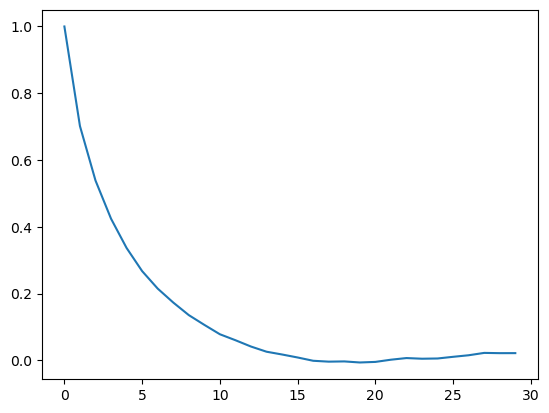

In [24]:
plt.plot(tau)
plt.show()

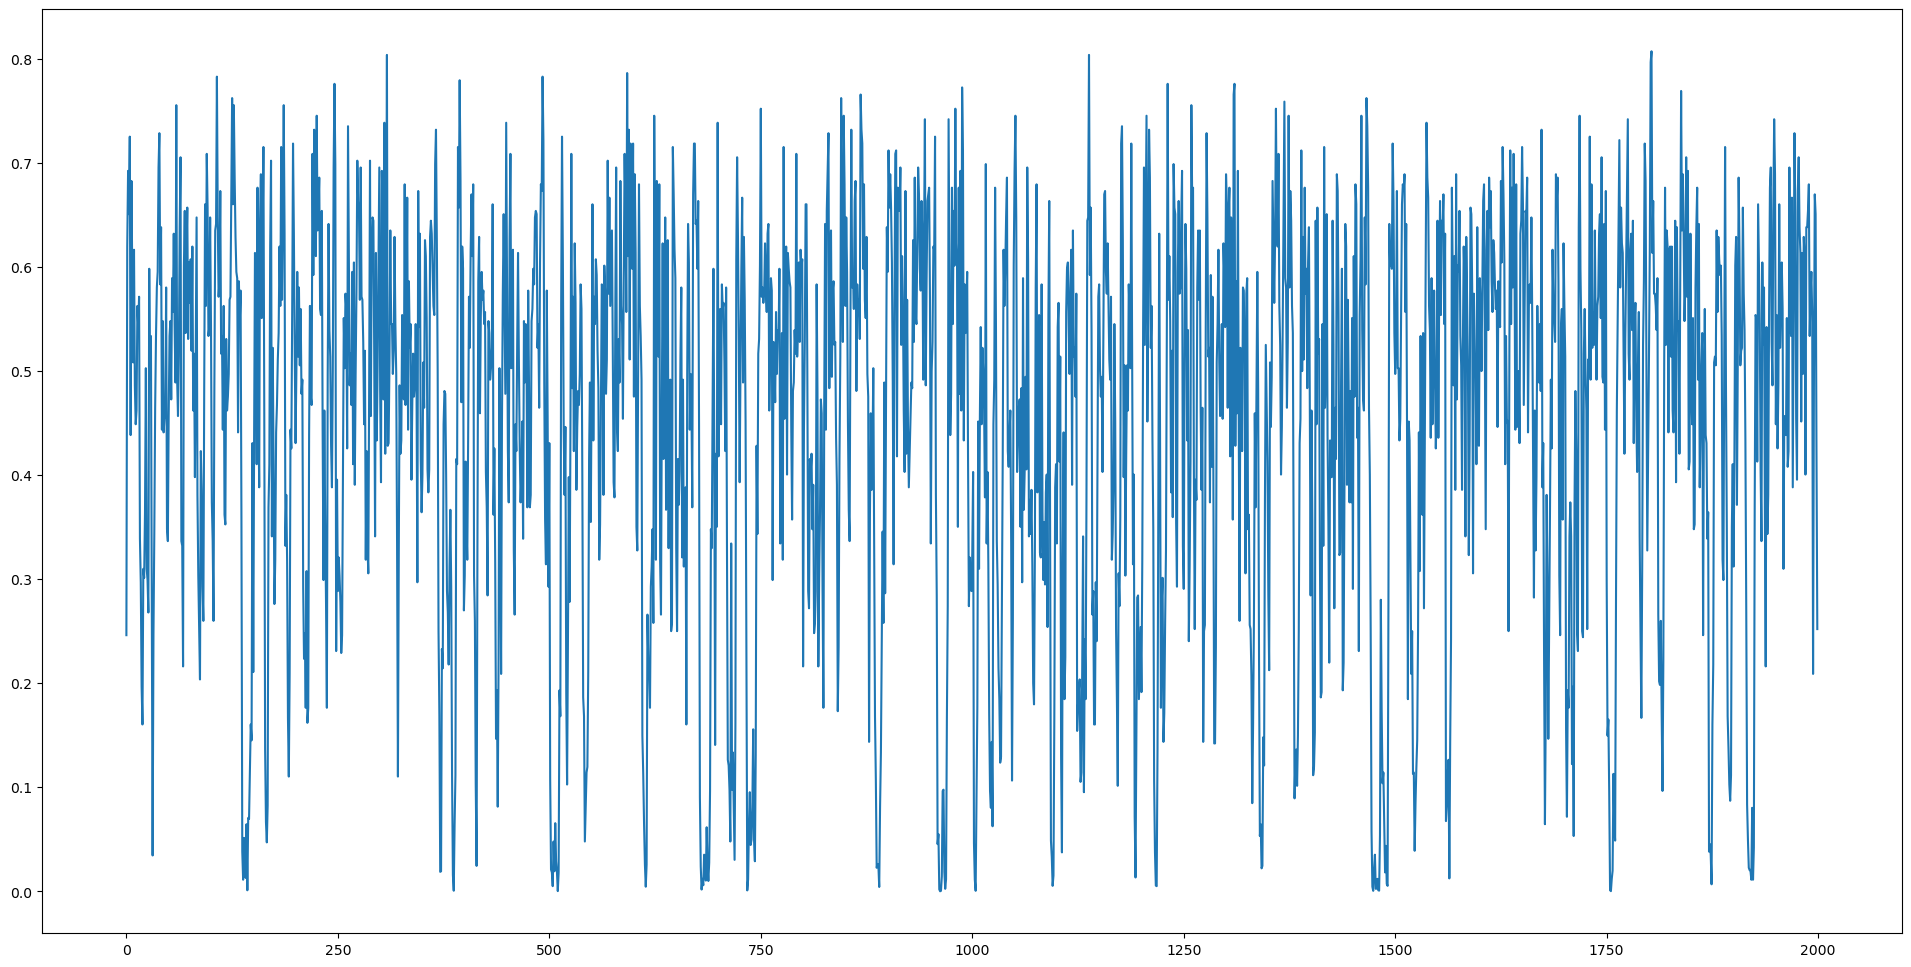

In [20]:
plt.figure(figsize=(24,12))
plt.plot(abs_m[:2000])
plt.show()

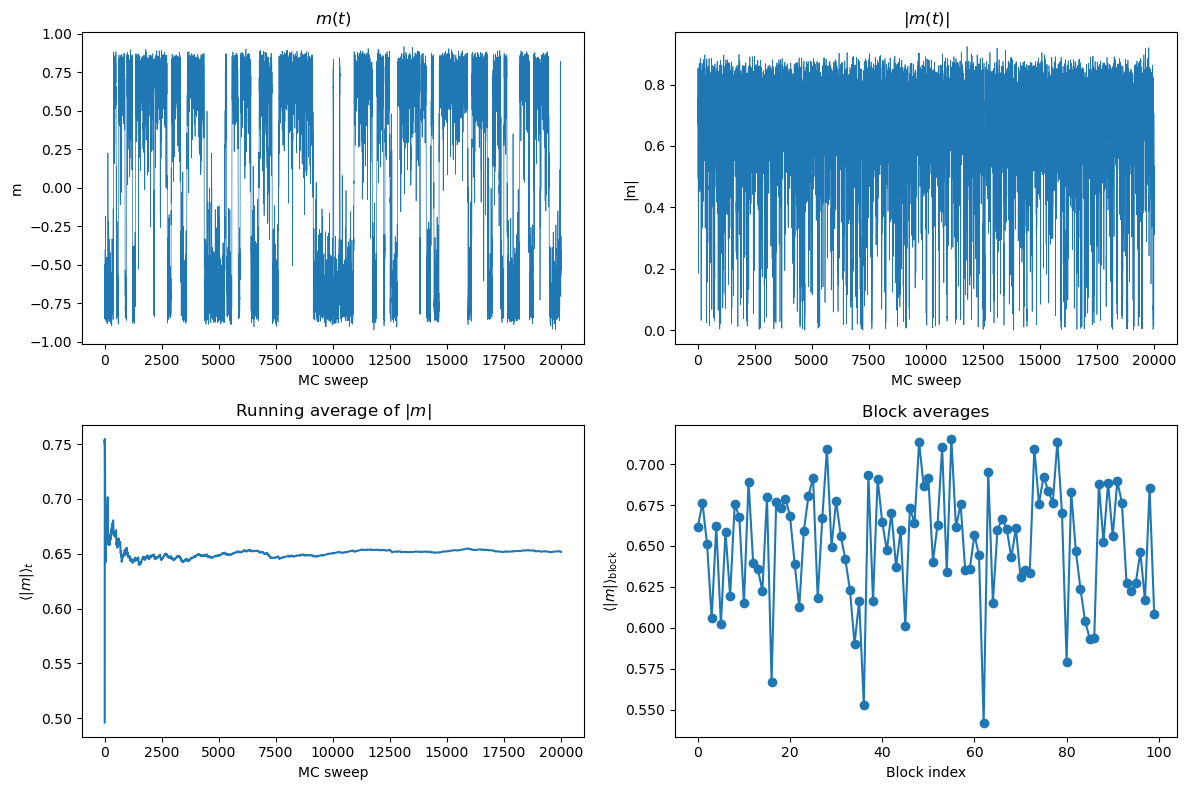

In [36]:
magnetization = spin_data['m']

# ============================================================
# Inputs
# ============================================================

m = np.asarray(magnetization)
m_abs = np.abs(m)

# ============================================================
# Running average
# ============================================================

running_mean = np.cumsum(m_abs) / np.arange(1, len(m_abs) + 1)

# ============================================================
# Reverse cumulative average
# ============================================================

reverse_mean = (
    np.cumsum(m_abs[::-1])[::-1]
    / np.arange(len(m_abs), 0, -1)
)

# ============================================================
# Block averages
# ============================================================

block_size = max(100, len(m)//100)

n_blocks = len(m_abs) // block_size

block_means = (
    m_abs[:n_blocks * block_size]
    .reshape(n_blocks, block_size)
    .mean(axis=1)
)

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# ------------------------------------------------------------
# Raw magnetization
# ------------------------------------------------------------

ax[0,0].plot(m, lw=0.5)
ax[0,0].set_title(r"$m(t)$")
ax[0,0].set_xlabel("MC sweep")
ax[0,0].set_ylabel("m")

# ------------------------------------------------------------
# Absolute magnetization
# ------------------------------------------------------------

ax[0,1].plot(m_abs, lw=0.5)
ax[0,1].set_title(r"$|m(t)|$")
ax[0,1].set_xlabel("MC sweep")
ax[0,1].set_ylabel("|m|")

# ------------------------------------------------------------
# Running average
# ------------------------------------------------------------

ax[1,0].plot(running_mean)
ax[1,0].set_title(r"Running average of $|m|$")
ax[1,0].set_xlabel("MC sweep")
ax[1,0].set_ylabel(r"$\langle |m| \rangle_t$")

# ------------------------------------------------------------
# Block averages
# ------------------------------------------------------------

ax[1,1].plot(block_means, marker='o')
ax[1,1].set_title("Block averages")
ax[1,1].set_xlabel("Block index")
ax[1,1].set_ylabel(r"$\langle |m| \rangle_{\rm block}$")

plt.tight_layout()
plt.show()

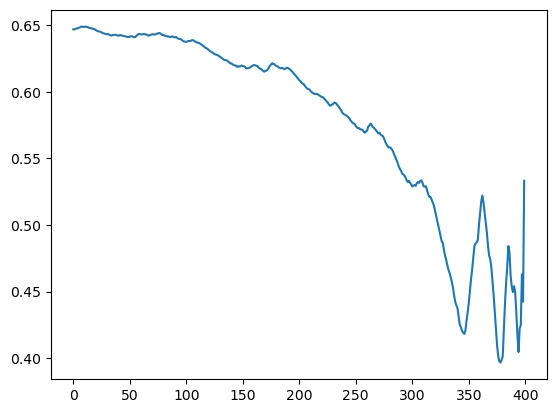

In [38]:
plt.plot(reverse_mean[-400:])

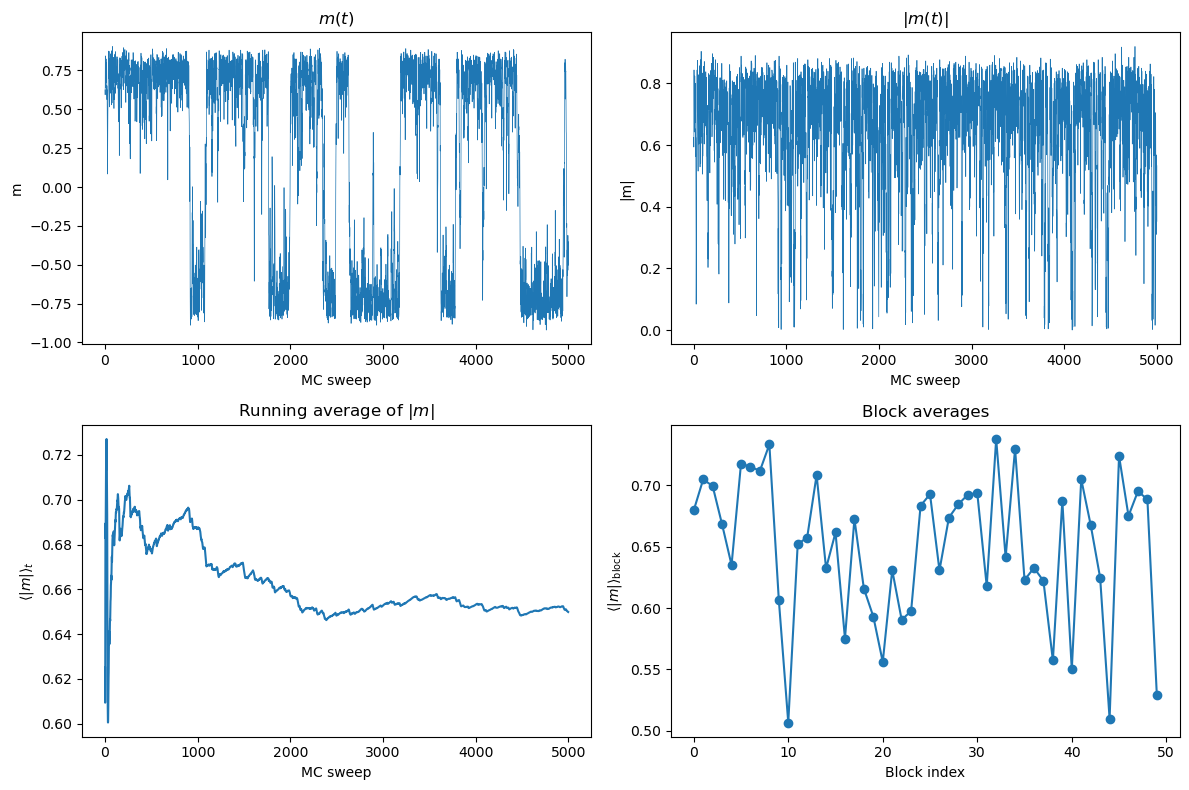

In [43]:
magnetization = spin_data['m'][-5000:]

# ============================================================
# Inputs
# ============================================================

m = np.asarray(magnetization)
m_abs = np.abs(m)

# ============================================================
# Running average
# ============================================================

running_mean = np.cumsum(m_abs) / np.arange(1, len(m_abs) + 1)

# ============================================================
# Reverse cumulative average
# ============================================================

reverse_mean = (
    np.cumsum(m_abs[::-1])[::-1]
    / np.arange(len(m_abs), 0, -1)
)

# ============================================================
# Block averages
# ============================================================

block_size = max(100, len(m)//100)

n_blocks = len(m_abs) // block_size

block_means = (
    m_abs[:n_blocks * block_size]
    .reshape(n_blocks, block_size)
    .mean(axis=1)
)

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# ------------------------------------------------------------
# Raw magnetization
# ------------------------------------------------------------

ax[0,0].plot(m, lw=0.5)
ax[0,0].set_title(r"$m(t)$")
ax[0,0].set_xlabel("MC sweep")
ax[0,0].set_ylabel("m")

# ------------------------------------------------------------
# Absolute magnetization
# ------------------------------------------------------------

ax[0,1].plot(m_abs, lw=0.5)
ax[0,1].set_title(r"$|m(t)|$")
ax[0,1].set_xlabel("MC sweep")
ax[0,1].set_ylabel("|m|")

# ------------------------------------------------------------
# Running average
# ------------------------------------------------------------

ax[1,0].plot(running_mean)
ax[1,0].set_title(r"Running average of $|m|$")
ax[1,0].set_xlabel("MC sweep")
ax[1,0].set_ylabel(r"$\langle |m| \rangle_t$")

# ------------------------------------------------------------
# Block averages
# ------------------------------------------------------------

ax[1,1].plot(block_means, marker='o')
ax[1,1].set_title("Block averages")
ax[1,1].set_xlabel("Block index")
ax[1,1].set_ylabel(r"$\langle |m| \rangle_{\rm block}$")

plt.tight_layout()
plt.show()

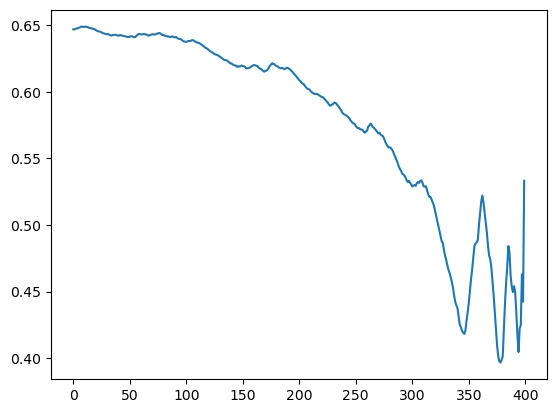

In [44]:
plt.plot(reverse_mean[-400:])